In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

plt.style.use('ggplot')
import plotly.graph_objects as go

In [4]:
ticker = "AAPL"

data = yf.download(
    ticker,
    start="2020-01-01",
    end="2025-01-01"
)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


In [5]:
data.shape

(1258, 5)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [7]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.377786,152.899566,149.680871,151.223470,9.057103e+07
std,41.851999,41.992363,41.629303,41.795805,5.324438e+07
min,54.163700,55.160698,51.324796,55.059309,2.323470e+07
25%,126.279112,127.397104,124.278530,125.724398,5.546825e+07
50%,149.968628,151.709757,148.037164,149.788875,7.628335e+07
75%,175.902031,177.452402,174.337249,175.708223,1.077425e+08
max,257.375580,258.448740,255.994420,256.550862,4.265100e+08


In [8]:
data.to_csv("data/apple_stock_data.csv")

In [9]:
data.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [10]:
data['Close'].head()

Ticker,AAPL
Date,
2020-01-02,72.333878
2020-01-03,71.630661
2020-01-06,72.201424
2020-01-07,71.861855
2020-01-08,73.017830


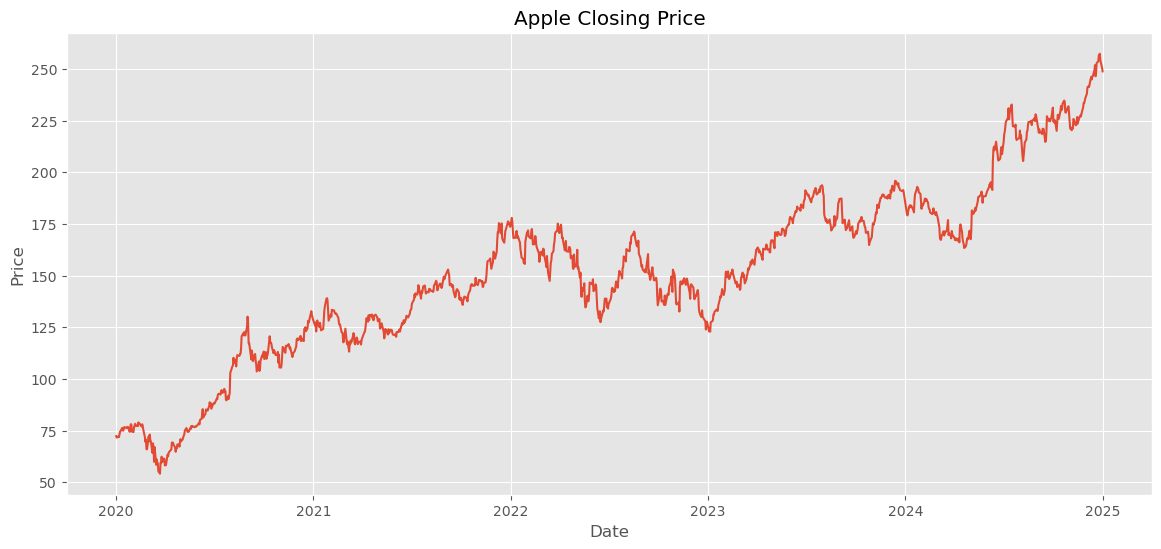

In [11]:
plt.figure(figsize=(14,6))

plt.plot(data['Close'])

plt.title('Apple Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')

plt.show()

# Moving Average graph


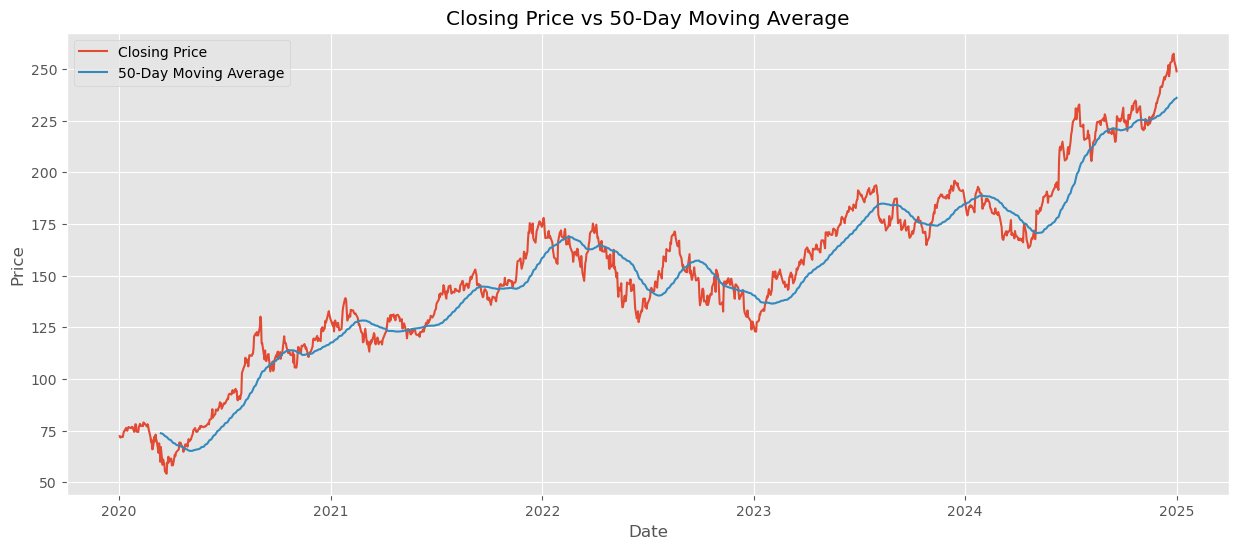

In [12]:
data['MA50'] = data['Close'].rolling(50).mean()

plt.figure(figsize=(15,6))

plt.plot(data['Close'], label='Closing Price')
plt.plot(data['MA50'], label='50-Day Moving Average')

plt.title('Closing Price vs 50-Day Moving Average')

plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()

plt.show()

# VOLUME GRAPH


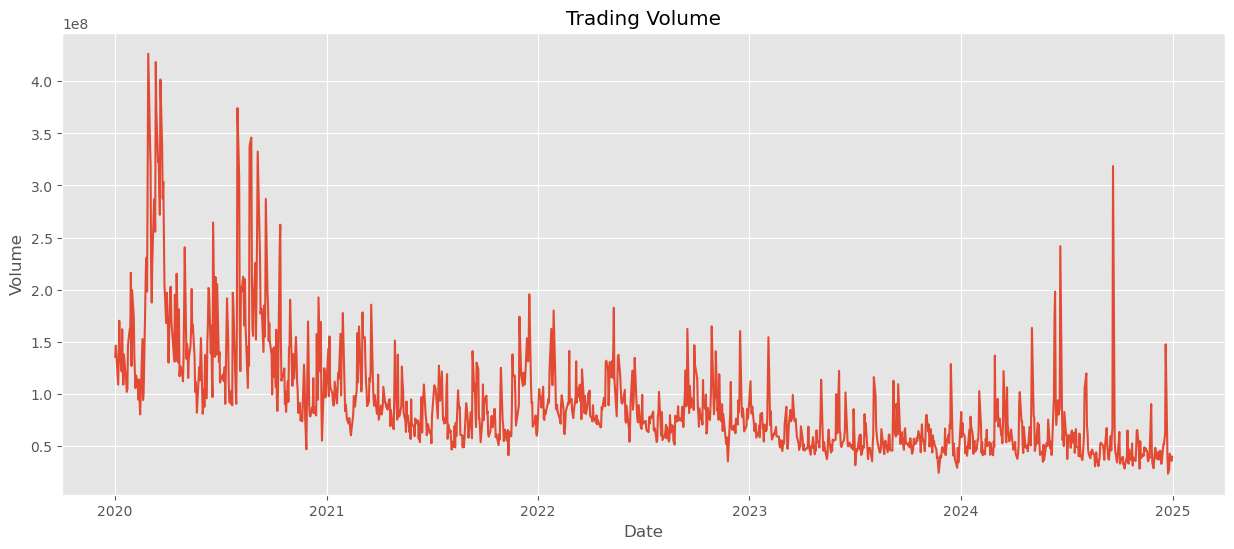

In [13]:
plt.figure(figsize=(15,6))

plt.plot(data['Volume'])

plt.title('Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.show()

In [14]:
data.columns = data.columns.droplevel(1)

In [15]:
print(data.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'MA50'], dtype='object', name='Price')


In [16]:
fig = go.Figure(data=[go.Candlestick(
    x=data.index,
    open=data['Open'],
    high=data['High'],
    low=data['Low'],
    close=data['Close']
)])

fig.update_layout(
    title='Candlestick Chart',
    xaxis_title='Date',
    yaxis_title='Price'
)

fig.show()

# Phase 2 

In [17]:
from sklearn.preprocessing import MinMaxScaler

In [18]:
closing_price = data[['Close']] # Select closing price 

In [19]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(closing_price)  # Scale data

In [20]:
scaled_data[:5]

array([[0.08941494],
       [0.08595443],
       [0.08876314],
       [0.08709213],
       [0.09278065]])

In [21]:
x_data = []
y_data = []

In [22]:
for i in range(60, len(scaled_data)):
    
    x_data.append(scaled_data[i-60:i])
    
    y_data.append(scaled_data[i])

In [23]:
x_data = np.array(x_data)
y_data = np.array(y_data)

In [24]:
print(x_data.shape)
print(y_data.shape)

(1198, 60, 1)
(1198, 1)


In [25]:
split = int(len(x_data) * 0.8)

x_train = x_data[:split]
y_train = y_data[:split]

x_test = x_data[split:]
y_test = y_data[split:]  # Split training data 

In [26]:
print(x_train.shape)
print(x_test.shape)

(958, 60, 1)
(240, 60, 1)


# Phase 3

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [28]:
model = Sequential()

# LSTM Model

In [29]:
model.add(LSTM(
    units=50,
    return_sequences=True,
    input_shape=(x_train.shape[1], 1)
))

model.add(Dropout(0.2))

D:\anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [30]:
model.add(LSTM(
    units=50,
    return_sequences=True
))

model.add(Dropout(0.2))

In [31]:
model.add(LSTM(
    units=50
))

model.add(Dropout(0.2))

In [32]:
model.add(Dense(units=1))

In [33]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 179ms/step - loss: 0.0262 - val_loss: 0.0196
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0043 - val_loss: 0.0081
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - loss: 0.0034 - val_loss: 0.0050
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 0.0031 - val_loss: 0.0058
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - loss: 0.0030 - val_loss: 0.0058
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - loss: 0.0028 - val_loss: 0.0016
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0026 - val_loss: 0.0035
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0027 - val_loss: 0.0080
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 0.0024 - val_loss: 0.0019
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - loss: 0.0027 - val_loss: 0.0014
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/ste

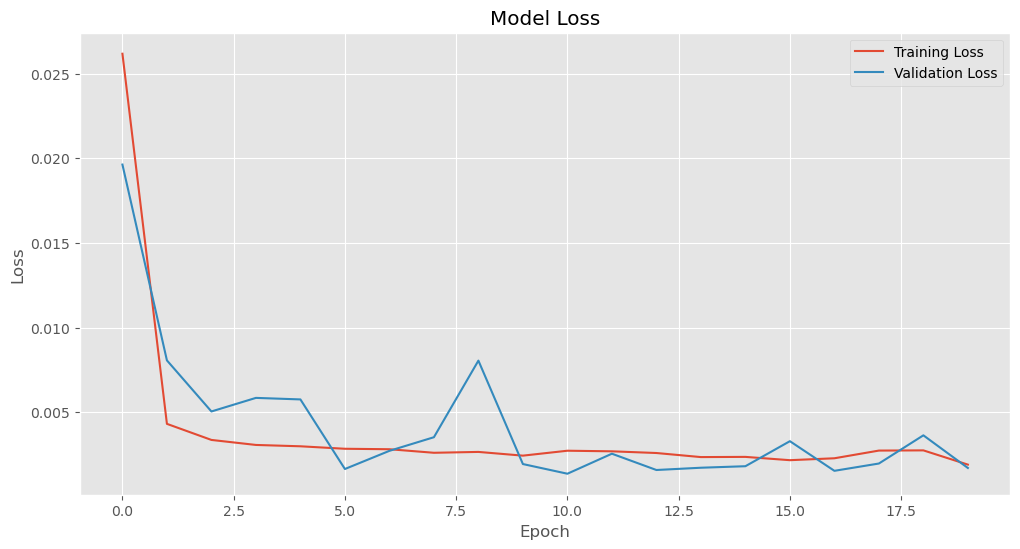

In [36]:
plt.figure(figsize=(12,6))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

In [37]:
predictions = model.predict(x_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step


In [38]:
predictions = scaler.inverse_transform(predictions)

actual_prices = scaler.inverse_transform(y_test)

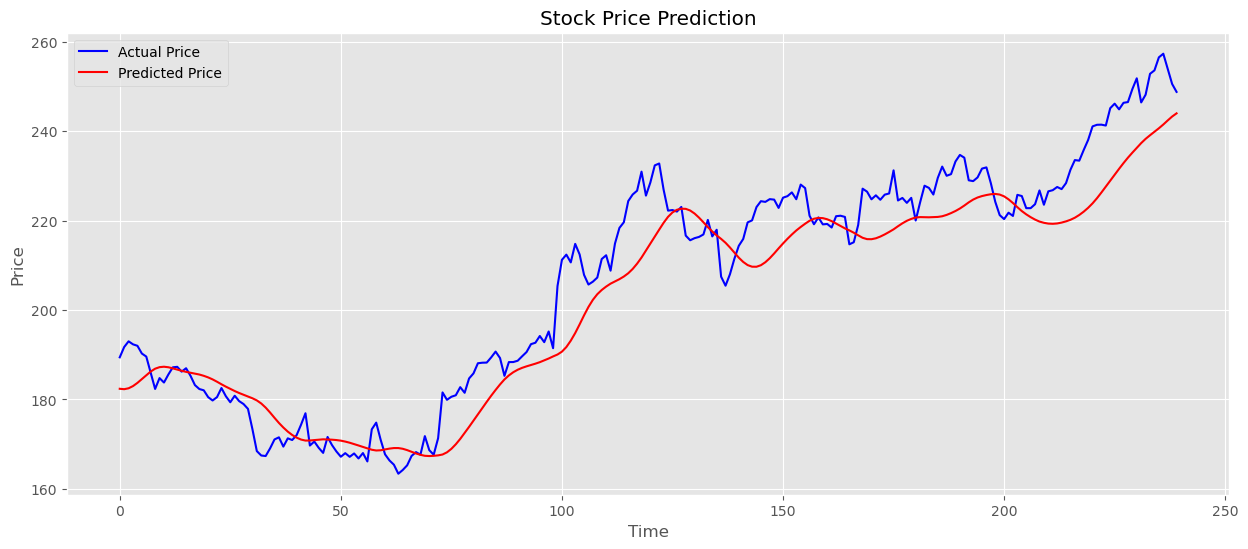

In [39]:
plt.figure(figsize=(15,6))

plt.plot(actual_prices, color='blue', label='Actual Price')

plt.plot(predictions, color='red', label='Predicted Price')

plt.title('Stock Price Prediction')

plt.xlabel('Time')
plt.ylabel('Price')

plt.legend()

plt.show()

In [40]:
model.save("models/stock_prediction_model.h5")

# Import metrics 

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate RMSE

In [42]:
rmse = np.sqrt(mean_squared_error(actual_prices, predictions))

print("RMSE:", rmse)

RMSE: 8.391249423796362


In [43]:
mae = mean_absolute_error(actual_prices, predictions)

print("MAE:", mae)

MAE: 6.743640899658205


In [44]:
last_60_days = closing_price[-60:].values

In [45]:
last_60_days_scaled = scaler.transform(last_60_days)

D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but MinMaxScaler was fitted with feature names



In [46]:
X_future = []

X_future.append(last_60_days_scaled)

X_future = np.array(X_future)

In [47]:
future_price = model.predict(X_future)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


In [48]:
future_price = scaler.inverse_transform(future_price)

print("Predicted Next Day Closing Price:", future_price[0][0])

Predicted Next Day Closing Price: 244.49426


# RSI indicator 

In [49]:
def calculate_rsi(data, window=14):
    
    delta = data['Close'].diff()

    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss

    rsi = 100 - (100 / (1 + rs))

    return rsi

In [50]:
data['RSI'] = calculate_rsi(data)

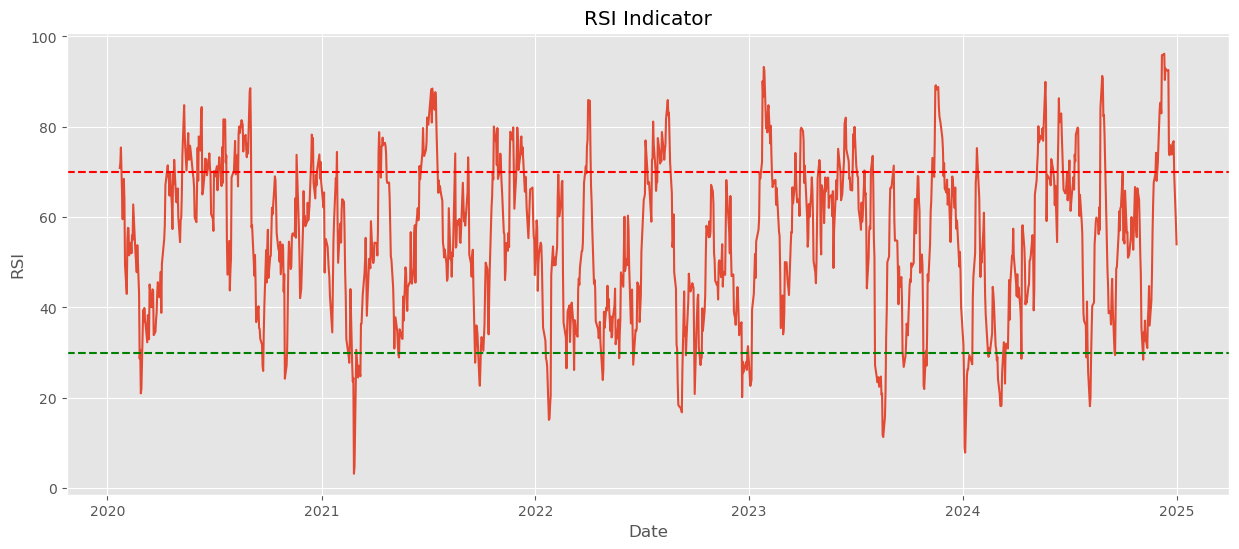

In [51]:
plt.figure(figsize=(15,6))

plt.plot(data['RSI'])

plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')

plt.title('RSI Indicator')

plt.xlabel('Date')
plt.ylabel('RSI')

plt.show()

In [52]:
data['Signal'] = 0

data.loc[data['RSI'] < 30, 'Signal'] = 1
data.loc[data['RSI'] > 70, 'Signal'] = -1

In [53]:
data[['Close', 'RSI', 'Signal']].tail(20)

Price,Close,RSI,Signal
Date,,,
2024-12-03,241.109528,85.314430,-1
2024-12-04,241.467239,85.009785,-1
2024-12-05,241.497040,82.962621,-1
2024-12-06,241.298309,95.837769,-1
2024-12-09,245.183517,96.019804,-1
2024-12-10,246.197037,96.163104,-1
2024-12-11,244.925156,90.355427,-1
2024-12-12,246.385834,92.894972,-1
2024-12-13,246.554764,92.504667,-1


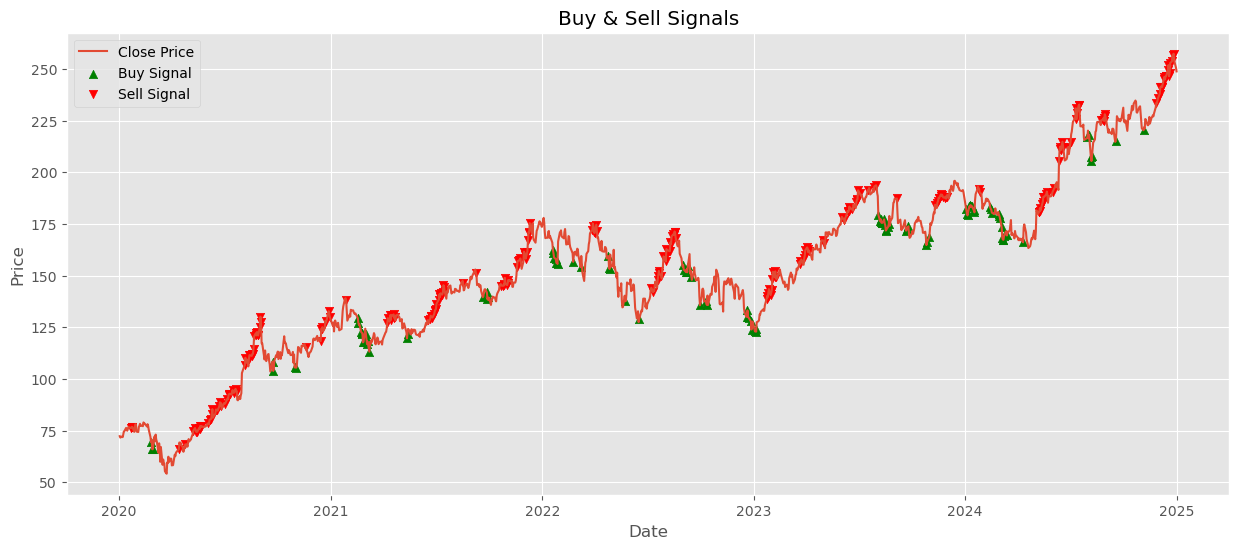

In [54]:
plt.figure(figsize=(15,6))

plt.plot(data['Close'], label='Close Price')

buy_signals = data[data['Signal'] == 1]
sell_signals = data[data['Signal'] == -1]

plt.scatter(
    buy_signals.index,
    buy_signals['Close'],
    marker='^',
    color='green',
    label='Buy Signal'
)

plt.scatter(
    sell_signals.index,
    sell_signals['Close'],
    marker='v',
    color='red',
    label='Sell Signal'
)

plt.title('Buy & Sell Signals')

plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()

plt.show()

In [55]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.
